# Data Extraction

In [2]:
import os
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms


class TinyImageDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        self.dir = os.path.join(root_dir, split)
        self.transform = transform
        
        # Take images Recursively
        self.image_paths = [
            str(p) for p in Path(self.dir).rglob('*.*') if p.suffix.upper() in ['.JPG', '.JPEG', '.PNG']
        ]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB") 

        # Apply transformation
        if self.transform:
            image = self.transform(image)

        return image, -1

transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

In [6]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_dataset = TinyImageDataset(root_dir='/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200', split='train', transform=transform)
val_dataset = TinyImageDataset(root_dir='/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200', split='val', transform=transform)
test_dataset = TinyImageDataset(root_dir='/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200', split='test', transform=transform)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, num_workers=4, pin_memory=True, prefetch_factor=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=4, pin_memory=True,prefetch_factor=2, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [7]:
import matplotlib.pyplot as plt
import torch

def display_image(tensor_img, title=""):
    img = tensor_img.cpu().detach()    

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean
    
    img = torch.clamp(img, 0, 1)
    
    #  [C, H, W] ->  [H, W, C]
    img = img.permute(1, 2, 0).numpy()
    
    plt.imshow(img)
    plt.title(title)
    plt.axis('off') 
    plt.show()

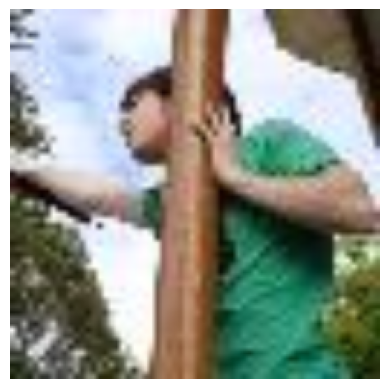

In [51]:
display_image(train_dataset[670][0])

Patches

In [8]:
import torch.nn as nn

IMAGE_SIZE = 224
PATCH_SIZE = 16
EMBED_DIM = 768
CHANNELS = 3
MASK_RATIO = 0.75
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2

class Patches(nn.Module):
    def __init__(self, img_size=IMAGE_SIZE, patch_size=PATCH_SIZE, channels=CHANNELS, embed_dim=EMBED_DIM):
        super().__init__()
        
        self.num_patches = NUM_PATCHES
        self.proj = nn.Conv2d(channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    # Randomly mask patches for given ratio
    def masking(self, x, mask_ratio=MASK_RATIO):
        B, P, D = x.shape       # [batch, num_patches, embed_dim]
        num_visible = int(P * (1 - mask_ratio))

        # noise for each patch to determine masking order
        noise = torch.rand(B, P, device=x.device)
        
        ids_shuffle = torch.argsort(noise)
        ids_restore = torch.argsort(ids_shuffle)

        visible_ids = ids_shuffle[:, : num_visible]
        
        # Gather visible patches
        x_masked = torch.gather(x, dim=1, index=visible_ids.unsqueeze(-1).repeat(1, 1, D))
        
        # Binary mask
        mask = torch.ones([B, P], device=x.device)
        mask[:, :num_visible] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)
        
        return x_masked, mask, ids_restore

    def forward(self, x):
        x = self.proj(x)                 # [B, embed_dim, p, p]
        x = x.flatten(2).transpose(1, 2) # [B, P, embed_dim]

        return x

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Model Architecture

In [10]:
LAYERS = 12
HEADS = 12

class Encoder(nn.Module):
    def __init__(self, embed_dim = EMBED_DIM, num_layers = LAYERS, num_heads = HEADS, num_patches = NUM_PATCHES, debug=False):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim), requires_grad=False)
        
        # base Transformer Encoder from Torch
        encoder_layer = nn.TransformerEncoderLayer(
            d_model = embed_dim,
            nhead = num_heads,
            dim_feedforward = embed_dim * 4,
            activation = "gelu",
            batch_first = True
        )
        self.blocks = nn.TransformerEncoder(encoder_layer, num_layers = num_layers)
        self.norm = nn.LayerNorm(embed_dim)
        self.debug = debug

    def forward(self, x, visible_ids):
        B, P, D = x.shape # [B, visible_patches, embed_dim]

        # Positional embeddings on visible patches only
        pos_embed = torch.gather(
            self.pos_embed.expand(B, -1, -1),
            dim=1,
            index = visible_ids.unsqueeze(-1).repeat(1, 1, D)
        )
        if self.debug:
            print(f"Post embed shape: {(pos_embed.shape)}")
        x = x + pos_embed

        # Transformer blocks
        x = self.blocks(x)
        x = self.norm(x)
        if self.debug:
            print(f"Transformer output(x) shape: {x.shape}")

        # Contextual features of visible patches
        return x

In [11]:
DECODER_EMBED_DIM = 384

class MaskedAutoencoder(nn.Module):
    def __init__(self, decoder_embed_dim=DECODER_EMBED_DIM, debug=False):
        super().__init__()

        # Encoder
        self.patch_embed = Patches(embed_dim = EMBED_DIM)
        self.encoder = Encoder(embed_dim=EMBED_DIM, num_layers=LAYERS, num_heads=HEADS, num_patches=NUM_PATCHES)

        # Encoder output -> Decoder dimension
        self.decoder_embed = nn.Linear(EMBED_DIM, decoder_embed_dim)
        
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, NUM_PATCHES, decoder_embed_dim), requires_grad=False)
        self.debug = debug
        
        # Decoder Transformer (Torch base)
        decoder_layer = nn.TransformerEncoderLayer(
            d_model=decoder_embed_dim, 
            nhead=6, 
            dim_feedforward=decoder_embed_dim * 4, 
            activation="gelu", 
            batch_first=True
        )

        self.decoder_blocks = nn.TransformerEncoder(decoder_layer, num_layers=LAYERS)
        self.decoder_norm = nn.LayerNorm(decoder_embed_dim)

        # Projection to reconstruct pixels
        self.decoder_pred = nn.Linear(decoder_embed_dim, PATCH_SIZE*PATCH_SIZE*CHANNELS)

    def forward(self, x, mask_ratio=MASK_RATIO):
        # Patching
        patches = self.patch_embed(x)
        x_visible, mask, ids_restore = self.patch_embed.masking(patches, mask_ratio)
        if self.debug:
            print(f"Patches shape: {patches.shape}")

        B, num_visible, _ = x_visible.shape
        visible_ids = torch.argsort(ids_restore, dim=1)[:, :num_visible]

        encoder_output = self.encoder(x_visible, visible_ids)           
        x_decoder = self.decoder_embed(encoder_output)
        if self.debug:
            print(f"Encoder output shape: {x_decoder.shape}")
        
        # learnable mask tokens
        mask_tokens = self.mask_token.repeat(B, NUM_PATCHES - num_visible, 1)
        x_full = torch.cat([x_decoder, mask_tokens], dim=1) 
        
        # Unshuffle visible tokens to their original order
        x_full = torch.gather(x_full, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x_full.shape[2]))
        x_full = x_full + self.decoder_pos_embed

        # Reconstruction of pixels
        x_decoded = self.decoder_blocks(x_full)
        x_decoded = self.decoder_norm(x_decoded)
        if self.debug:
            print(f"Decoder output shape: {x_decoder.shape}")

        # predicted pixel values
        pred = self.decoder_pred(x_decoded)
        return pred, mask

# Training

In [12]:
import torch
import torch.nn.functional as F


# Images [B, 3, 224, 224] -> [B, 196, 768]
def img_to_patches(imgs, patch_size=PATCH_SIZE):
    B, C, H, W = imgs.shape
    num_patches_h = H // patch_size
    num_patches_w = W // patch_size
    
    patches = imgs.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
    
    patches = patches.contiguous().view(B, C, num_patches_h * num_patches_w, patch_size, patch_size)
    patches = patches.permute(0, 2, 3, 4, 1).contiguous().view(B, num_patches_h * num_patches_w, -1)
    
    return patches

def mae_loss(imgs, pred, mask):
    target = img_to_patches(imgs)
    
    loss = (pred - target) ** 2
    loss = loss.mean(dim=-1) 
    loss = (loss * mask).sum() / mask.sum()
    
    return loss

In [13]:
LR = 1e-3
EPOCHS = 20

model = MaskedAutoencoder().to(device) 
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler('cuda')

In [14]:
from tqdm import tqdm

epoch_losses = [] 
val_losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_epoch_loss = 0.0

    train_loop = tqdm(enumerate(train_loader), total=len(train_loader), leave=False)
    train_loop.set_description(f"Epoch [{epoch}/{EPOCHS}] Training")
    
    for batch_idx, (images, _) in train_loop:
        images = images.to(device)
        
        # Zero gradients for this batch
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            predictions, mask = model(images, mask_ratio=MASK_RATIO) 
            # MSE on masked patches
            loss = mae_loss(images, predictions, mask) 
            
        # Scale the loss and backpropagate
        scaler.scale(loss).backward()
        
        # Unscale the gradients before clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Optimizer step and scaler update
        scaler.step(optimizer)
        scaler.update()
        
        total_epoch_loss += loss.item()
            
    # Calculate average loss for the entire epoch
    avg_loss = total_epoch_loss / len(train_loader)
    epoch_losses.append(avg_loss)

    # Validation Loss
    if epoch % 2 == 0:
        model.eval()
        total_val_loss = 0.0

        val_loop = tqdm(val_loader, total=len(val_loader), leave=False)
        val_loop.set_description(f"Epoch [{epoch}/{EPOCHS}] Validation")
        
        with torch.no_grad():
            for images, _ in val_loop:
                images = images.to(device)
                with torch.amp.autocast('cuda'):
                    predictions, mask = model(images, mask_ratio=MASK_RATIO)
                    loss = mae_loss(images, predictions, mask)
                total_val_loss += loss.item()
        
        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        print(f"Validation Loss after Epoch {epoch}: {avg_val_loss:.4f}")

    
    scheduler.step()
    
    print(f"-- End of Epoch {epoch} | Average Loss: {avg_loss:.4f} --")

print("Training Complete ...")

-- End of Epoch 1 | Average Loss: 1.3833 --


Validation Loss after Epoch 2: 1.3842
-- End of Epoch 2 | Average Loss: 1.3805 --


-- End of Epoch 3 | Average Loss: 1.3800 --


Validation Loss after Epoch 4: 1.3860
-- End of Epoch 4 | Average Loss: 1.3803 --


-- End of Epoch 5 | Average Loss: 1.3801 --


...

Validation Loss after Epoch 16: 1.3847
-- End of Epoch 16 | Average Loss: 1.3800 --


-- End of Epoch 17 | Average Loss: 1.3801 --


Validation Loss after Epoch 18: 1.3851
-- End of Epoch 18 | Average Loss: 1.3799 --


-- End of Epoch 19 | Average Loss: 1.3802 --


Validation Loss after Epoch 20: 1.3856
-- End of Epoch 20 | Average Loss: 1.3797 --
Training Complete ...


In [16]:
checkpoint = {
    'epochs_completed': EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'hyperparameters': {
        'embed_dim': EMBED_DIM,
        'learning_rate': LR,
        'batch_size': BATCH_SIZE,
        'mask_ratio': 0.75
    }
}

save_path = 'mae_model_final.pth'
torch.save(checkpoint, save_path)


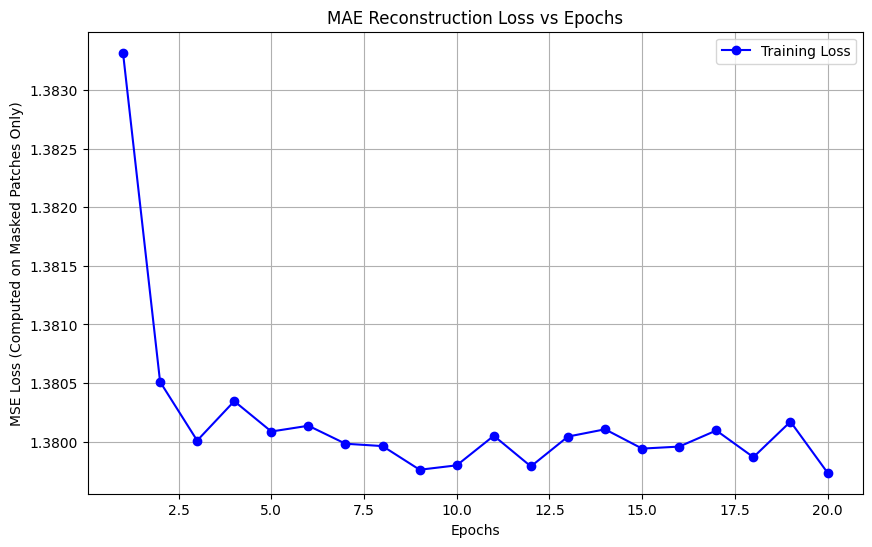

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), epoch_losses, marker='o', linestyle='-', color='b', label='Training Loss')
plt.title('MAE Reconstruction Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss (Computed on Masked Patches Only)')
plt.grid(True)
plt.legend()
plt.show()

# Evaluation

In [18]:
# Convert model output to original Image
def unpatch(patched_tensor, patch_size=16):
    B = patched_tensor.shape[0]
    H = W = int(patched_tensor.shape[1] ** 0.5) # 14
    C = patched_tensor.shape[2] // (patch_size ** 2) # 3
    
    x = patched_tensor.reshape(B, H, W, patch_size, patch_size, C)
    x = x.permute(0, 5, 1, 3, 2, 4)
    
    x = x.reshape(B, C, H * patch_size, W * patch_size)
    
    return x # [B, C, W, H]

In [19]:
def apply_visual_mask(imgs, mask, patch_size=16):
    B, C, H, W = imgs.shape
    
    # Expand mask to pixel level
    mask_pixels = mask.unsqueeze(-1).repeat(1, 1, patch_size**2 * C)
    mask_pixels = unpatch(mask_pixels, patch_size)
    
    masked_img = imgs * (1 - mask_pixels)
    return masked_img

In [20]:
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
import numpy as np

psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

def evaluate_and_visualize(model, dataloader, device, num_samples=5):
    model.eval()
    
    images, _ = next(iter(dataloader))
    images = images[:num_samples].to(device)
    
    with torch.no_grad():
        # Get model predictions
        predictions, mask = model(images, mask_ratio=0.75)
        
        # Convert predictions back to image shape
        reconstructed_imgs = unpatch(predictions)
        
        # Create the visual masked inputs
        masked_imgs = apply_visual_mask(images, mask)
        

        mask_pixels = unpatch(mask.unsqueeze(-1).repeat(1, 1, 16**2 * 3))
        final_reconstruction = images * (1 - mask_pixels) + reconstructed_imgs * mask_pixels

    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)
    
    images_denorm = torch.clamp(images * std + mean, 0, 1)
    masked_denorm = torch.clamp(masked_imgs * std + mean, 0, 1)
    recon_denorm = torch.clamp(final_reconstruction * std + mean, 0, 1)

    #  Calculate Metrics
    psnr_score = psnr_metric(recon_denorm, images_denorm)
    ssim_score = ssim_metric(recon_denorm, images_denorm)
    
    print(f"Quantitative Evaluation:")
    print(f"\tAverage PSNR: {psnr_score.item():.2f} dB")
    print(f"\tAverage SSIM: {ssim_score.item():.4f}\n")

    # Plotting
    fig, axes = plt.subplots(num_samples, 3, figsize=(10, 3 * num_samples))
    
    for i in range(num_samples):
        orig = images_denorm[i].cpu().permute(1, 2, 0).numpy()
        mask_vis = masked_denorm[i].cpu().permute(1, 2, 0).numpy()
        recon = recon_denorm[i].cpu().permute(1, 2, 0).numpy()
        
        # Original
        axes[i, 0].imshow(orig)
        axes[i, 0].axis('off')
        if i == 0: axes[i, 0].set_title("Ground Truth")
            
        # Masked
        axes[i, 1].imshow(mask_vis)
        axes[i, 1].axis('off')
        if i == 0: axes[i, 1].set_title("Masked Input (75%)")
            
        # Reconstruction
        axes[i, 2].imshow(recon)
        axes[i, 2].axis('off')
        if i == 0: axes[i, 2].set_title("MAE Reconstruction")
            
    plt.tight_layout()
    plt.show()


In [21]:
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
import numpy as np


psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

def evaluate_and_visualize(model, dataloader, device, num_samples=5):
    model.eval()
    
    images, _ = next(iter(dataloader))
    images = images[:num_samples].to(device)
    
    with torch.no_grad():
        # Get model predictions
        predictions, mask = model(images, mask_ratio=0.75)
        
        # Convert predictions back to image shape
        reconstructed_imgs = unpatch(predictions)
        
        # Create the visual masked inputs
        masked_imgs = apply_visual_mask(images, mask)
        
        mask_pixels = unpatch(mask.unsqueeze(-1).repeat(1, 1, 16**2 * 3))
        final_reconstruction = images * (1 - mask_pixels) + reconstructed_imgs * mask_pixels

    # Denormalization of Image
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)
    images_denorm = torch.clamp(images * std + mean, 0, 1)
    masked_denorm = torch.clamp(masked_imgs * std + mean, 0, 1)
    recon_denorm = torch.clamp(final_reconstruction * std + mean, 0, 1)

    # Direct Clapming (If no normalization)
    # images_denorm = torch.clamp(images, 0, 1)
    # masked_denorm = torch.clamp(masked_imgs, 0, 1)
    # recon_denorm = torch.clamp(final_reconstruction, 0, 1)

    # Calculate Metrics
    psnr_score = psnr_metric(recon_denorm, images_denorm)
    ssim_score = ssim_metric(recon_denorm, images_denorm)
    
    print(f"Quantitative Evaluation:")
    print(f"\tAverage PSNR: {psnr_score.item():.2f} dB")
    print(f"\tAverage SSIM: {ssim_score.item():.4f}\n")

    # Plotting
    fig, axes = plt.subplots(num_samples, 3, figsize=(10, 3 * num_samples))
    
    for i in range(num_samples):
        orig = images_denorm[i].cpu().permute(1, 2, 0).numpy()
        mask_vis = masked_denorm[i].cpu().permute(1, 2, 0).numpy()
        recon = recon_denorm[i].cpu().permute(1, 2, 0).numpy()
        
        # Original
        axes[i, 0].imshow(orig)
        axes[i, 0].axis('off')
        if i == 0: axes[i, 0].set_title("Ground Truth")
            
        # Masked
        axes[i, 1].imshow(mask_vis)
        axes[i, 1].axis('off')
        if i == 0: axes[i, 1].set_title("Masked Input (75%)")
            
        # Reconstruction
        axes[i, 2].imshow(recon)
        axes[i, 2].axis('off')
        if i == 0: axes[i, 2].set_title("MAE Reconstruction")
            
    plt.tight_layout()
    plt.show()

Quantitative Evaluation:
	Average PSNR: 14.17 dB
	Average SSIM: 0.4803



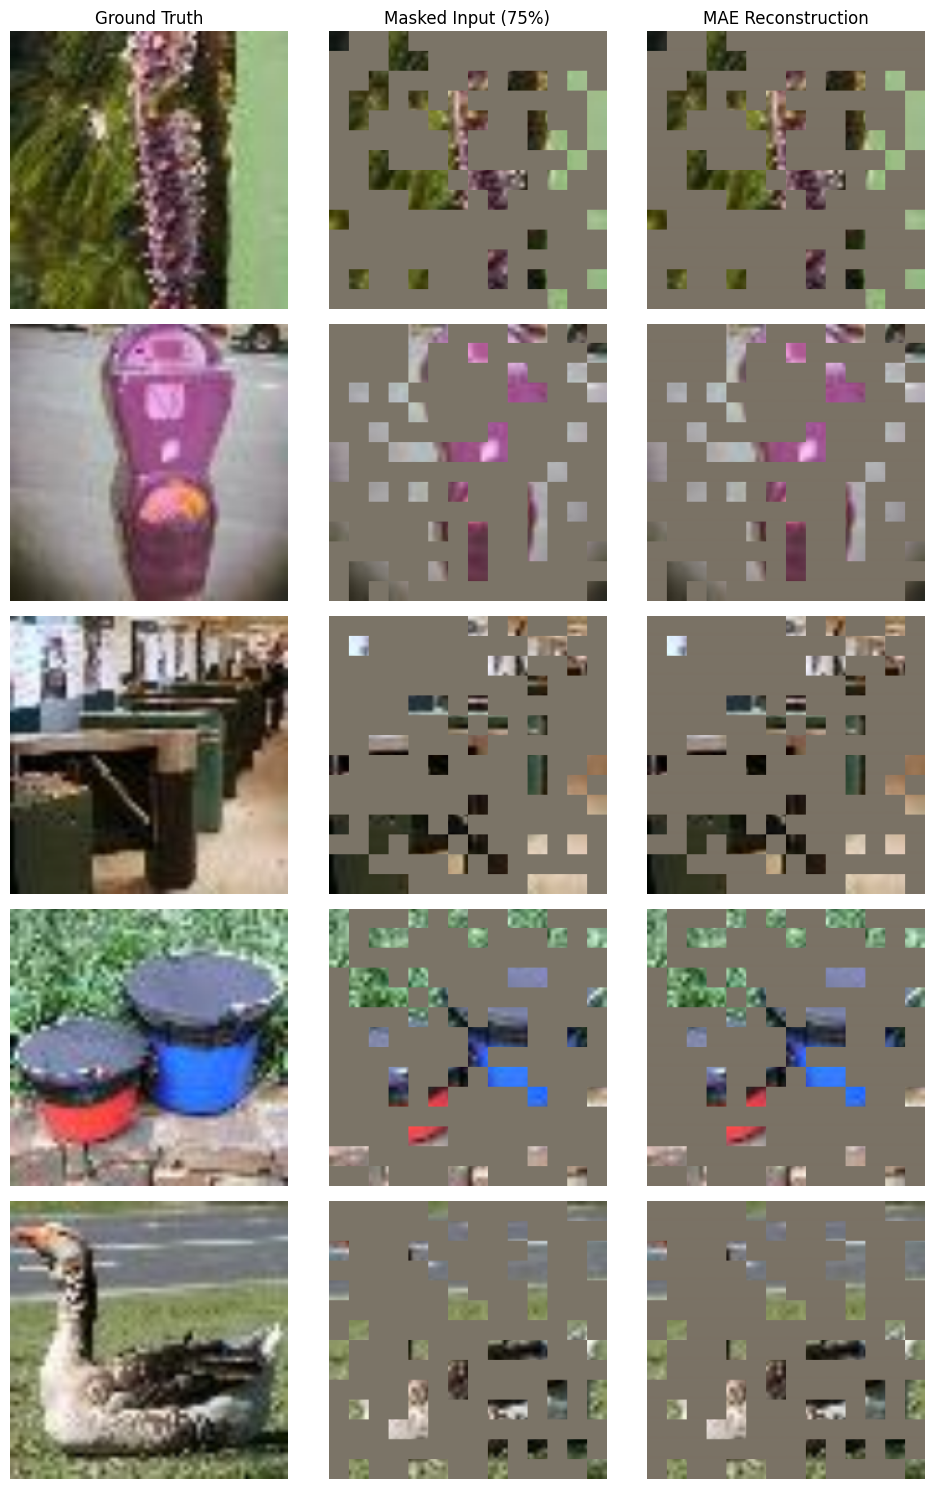

In [23]:
evaluate_and_visualize(model, test_loader, device, num_samples=5)